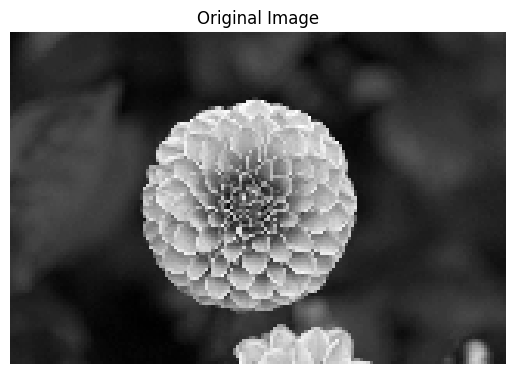

Image shape: (107, 160)
Pixel values range: 3 to 211
Converged in 4 iterations
Converged in 19 iterations
Converged in 6 iterations
Converged in 12 iterations
Converged in 35 iterations
Converged in 21 iterations
Converged in 71 iterations
Converged in 9 iterations
Converged in 27 iterations
Converged in 50 iterations


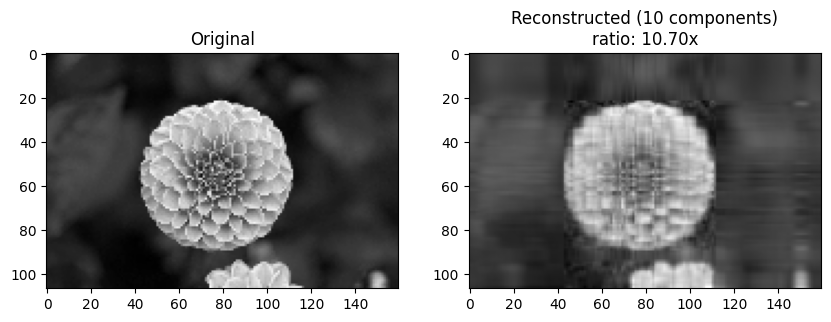

Converged in 4 iterations


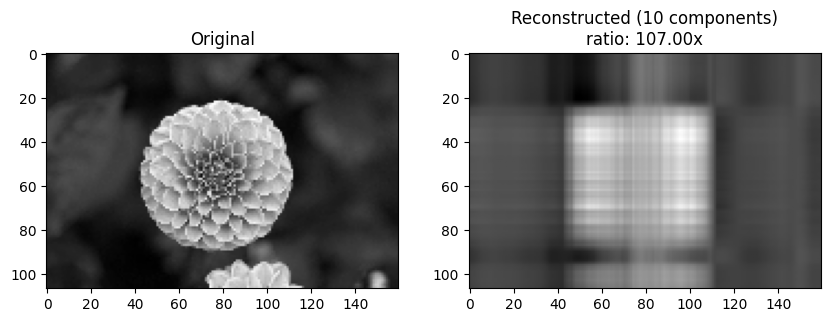

Converged in 4 iterations
Converged in 19 iterations
Converged in 6 iterations
Converged in 12 iterations
Converged in 35 iterations
Converged in 21 iterations
Converged in 71 iterations
Converged in 9 iterations
Converged in 27 iterations
Converged in 50 iterations
Converged in 21 iterations
Converged in 64 iterations
Converged in 25 iterations
Converged in 74 iterations
Converged in 87 iterations
Converged in 15 iterations
Converged in 53 iterations
Converged in 29 iterations
Converged in 66 iterations
Converged in 53 iterations
Converged in 93 iterations
Converged in 15 iterations
Converged in 35 iterations
Converged in 66 iterations
Converged in 70 iterations
Converged in 52 iterations
Converged in 20 iterations
Converged in 68 iterations
Converged in 53 iterations
Converged in 51 iterations
Converged in 21 iterations
Converged in 134 iterations
Converged in 38 iterations
Converged in 125 iterations
Converged in 71 iterations
Converged in 25 iterations
Converged in 38 iterations
Co

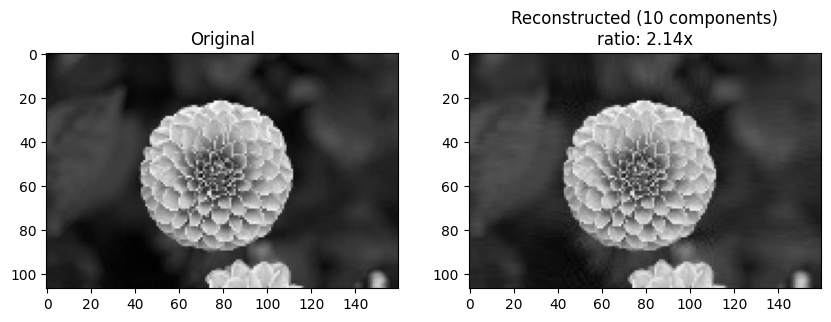

Converged in 4 iterations
Converged in 19 iterations
Converged in 6 iterations
Converged in 12 iterations
Converged in 35 iterations
Converged in 21 iterations
Converged in 71 iterations
Converged in 9 iterations
Converged in 27 iterations
Converged in 50 iterations
Converged in 21 iterations
Converged in 64 iterations
Converged in 25 iterations
Converged in 74 iterations
Converged in 87 iterations
Converged in 15 iterations
Converged in 53 iterations
Converged in 29 iterations
Converged in 66 iterations
Converged in 53 iterations
Converged in 93 iterations
Converged in 15 iterations
Converged in 35 iterations
Converged in 66 iterations
Converged in 70 iterations
Converged in 52 iterations
Converged in 20 iterations
Converged in 68 iterations
Converged in 53 iterations
Converged in 51 iterations
Converged in 21 iterations
Converged in 134 iterations
Converged in 38 iterations
Converged in 125 iterations
Converged in 71 iterations
Converged in 25 iterations
Converged in 38 iterations
Co

KeyboardInterrupt: 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import sys
sys.path.append('../lib/linear_algebra')
sys.path.append('../lib/algorithms')
from matrix import Matrix
from vector import Vector
from PCA import PCA
from PIL import Image
import requests
from io import BytesIO
from sklearn.datasets import load_sample_image

### USING SKLEARN ONLY TO GET AN IMAGE.

def load_sample_image_simple() -> np.ndarray:
    """
    Load a sample grayscale image for compression experiments.

    Returns:
        2D numpy array of shape (height, width) with pixel values
    """
    img = load_sample_image('flower.jpg')
    img_gray = img.mean(axis=2)
    img_small = img_gray[::4, ::4]

    return img_small.astype(np.uint8)
    
def compress_image_pca(image: np.ndarray, n_components: int) -> Tuple[np.ndarray, float, 'PCA']:
    """
    Compress a single image using PCA

    Strategy: Treat each row of the image as a data point, each column
    as a feature. Find principal components across rows.

    Args:
        image: 2D array of shape (height, width)
        n_components: Number of principal components to keep

    Returns:
        reconstruced: reconstructed image
        compression_ratio: Original size / compressed size
        pca: Fitted PCA object

    How it works:
    1. Each row of the image is a 1D vector of pixel values
    2. We have 'height' such vectors, each with 'width' features
    3. PCA finds patterns across these row vectors
    4. We keep only top n_components patterns
    5. Reconstruct the image from these components

    Compression ratio calculation:
    - Original: height * width values
    - Compressed: n_components * width (components) +
                  n_components * height (coefficients)
    """
    image_pca = PCA(n_components)
    transformed_image = image_pca.fit_transform(image)
    reconstructed_image = image_pca.inverse_transform(transformed_image)
    original_size = image.shape[0] * image.shape[1]
    compressed_size = (image_pca.components_.shape[0] * image_pca.components_.shape[1])
    + (transformed_image.shape[0] * transformed_image.shape[1]) 
    compression_ratio = original_size / compressed_size
    return (reconstructed_image, compression_ratio, image_pca)
            
    

#Load and Visualize
original_image = load_sample_image_simple()
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

print(f"Image shape: {original_image.shape}")
print(f"Pixel values range: {original_image.min()} to {original_image.max()}")

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=10)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (10 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=1)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (10 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=50)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (10 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=100)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (10 components)\nratio: {ratio:.2f}x')
plt.show()

    